In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/PARK7/unbiased_1us/'

In [2]:
# dataframe
df = pd.DataFrame()
residues = np.arange(1,190)
df['Residue'] = residues

# isolated
nsims=3
rmsf = []
for i in range(1,nsims+1):
    dat = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][:189]
    rmsf.append(dat)
rmsf = np.array(rmsf)
mu = np.mean(rmsf,axis=0)*10 # convert to Angstrom
err = np.std(rmsf,axis=0)*10/np.sqrt(nsims)

df['Isolated Avg.'] = mu
df['Isolated Err.'] = err

df.to_csv('RMSF_data_chainA.csv')
df[:10]

,Residue,Isolated Avg.,Isolated Err.
0,1,4.846333,0.253402
1,2,2.650333,0.217118
2,3,1.262333,0.141205
3,4,0.574000,0.008219
4,5,0.528667,0.005423
5,6,0.396333,0.006080
6,7,0.360333,0.005969
7,8,0.345667,0.005193
8,9,0.376000,0.007587
9,10,0.398667,0.007921


In [3]:
# dataframe
df = pd.DataFrame()
residues = np.arange(1,190)
df['Residue'] = residues

# isolated
nsims=3
rmsf = []
for i in range(1,nsims+1):
    dat = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][189:]
    rmsf.append(dat)
rmsf = np.array(rmsf)
mu = np.mean(rmsf,axis=0)*10 # convert to Angstrom
err = np.std(rmsf,axis=0)*10/np.sqrt(nsims)

df['Isolated Avg.'] = mu
df['Isolated Err.'] = err

df.to_csv('RMSF_data_chainB.csv')
df[:10]

,Residue,Isolated Avg.,Isolated Err.
0,1,5.273333,0.539993
1,2,3.050333,0.498612
2,3,1.589000,0.360154
3,4,0.635000,0.028241
4,5,0.544000,0.010656
5,6,0.399333,0.005171
6,7,0.368667,0.004579
7,8,0.352000,0.006128
8,9,0.386667,0.007977
9,10,0.409667,0.009444


In [4]:
# dataframe
df = pd.DataFrame()
residues = np.arange(1,190)
df['Residue'] = residues

# isolated
nsims=3
rmsf = []
for i in range(1,nsims+1):
    dat = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][:189]
    dat2 = np.loadtxt(path+'sim{}/rmsf_CA.xvg'.format(i),skiprows=17)[:,1][189:]
    
    rmsf.append(dat)
    rmsf.append(dat2)
rmsf = np.array(rmsf)
mu = np.mean(rmsf,axis=0)*10 # convert to Angstrom
err = np.std(rmsf,axis=0)*10/np.sqrt(nsims*2)

df['Isolated Avg.'] = mu
df['Isolated Err.'] = err

df.to_csv('RMSF_data_avgchain.csv')
df[:10]

,Residue,Isolated Avg.,Isolated Err.
0,1,5.059833,0.310722
1,2,2.850333,0.283910
2,3,1.425667,0.204594
3,4,0.604500,0.019270
4,5,0.536333,0.006748
5,6,0.397833,0.004037
6,7,0.364500,0.004128
7,8,0.348833,0.004219
8,9,0.381333,0.005919
9,10,0.404167,0.006559


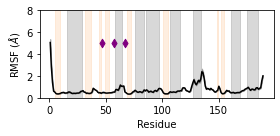

In [9]:
# average RMSF of chain A and chain B
df = pd.read_csv('RMSF_data_avgchain.csv')

ymax = 8

# secondary structure elements
# Beta strands based on DSSP:
beta_start = [5,16,32,44,49,58,69,76,86,101,107,127,148,152,161,175]
beta_end = [10,29,37,46,53,64,72,84,97,105,116,134,149,155,169,185]
beta_start = np.array(beta_start)
beta_end = np.array(beta_end)
strand_names = ['S1','H1','S2','S3','S4','H2','S5','H3','H4','S6','H5','H6','S7','S8','H7','H8']


plt.figure(figsize = (4,2))

colors = ['black']
constructs = ['Isolated']

for c,con in zip(colors,constructs):
    plt.plot(df['Residue'],df['{} Avg.'.format(con)],color = c,label = con)
    plt.fill_between(df['Residue'],df['{} Avg.'.format(con)]-df['{} Err.'.format(con)],df['{} Avg.'.format(con)]+df['{} Err.'.format(con)],color = c,alpha = 0.3)
    

plt.ylim(0,ymax)
# secondary structure
#for i in range(len(beta_start)):
    #plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
#for i in range(len(beta_start)):
    #plt.text((beta_start[i]+beta_end[i])/2-3,ymax*0.85,strand_names[i],fontsize = 10)
    
for i in range(len(beta_start)):
    if 'H' in strand_names[i]:
        col='grey'
    elif 'S' in strand_names[i]:
        col='#FEC89A'
    plt.axvspan(beta_start[i],beta_end[i],color = col,alpha = 0.3)
#for i in range(len(beta_start)):
    #plt.text((beta_start[i]+beta_end[i])/2-3,ymax*0.85,strand_names[i],fontsize = 10)
    
# buried PTM sites
plt.scatter([67],[5],color = 'purple',marker='d')
plt.scatter([57],[5],color = 'purple',marker='d')
plt.scatter([47],[5],color = 'purple',marker='d')

    
plt.xlabel('Residue')
plt.ylabel('RMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('RMSF_comparison_avgchain.pdf')









In [10]:
# map RMSF on structure
s = md.Universe('../pdb_files/processed.pdb')
natoms = len(s.atoms)
residues = s.atoms.resids
newtempfactors = []
for res in residues:
    idx = list(df['Residue']).index(res)
    newtempfactors.append(float(df['Isolated Avg.'][idx]))
newtempfactors = np.array(newtempfactors)
s.atoms.tempfactors=newtempfactors
s.select_atoms('all').write('input_complex_RMSF_bfactor_avgchain.pdb')
print('Done')

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/MDAnalysis/topology/guessers.py:80: UserWarning: Failed to guess the mass for the following atom types: 
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/MDAnalysis/topology/PDBParser.py:330: UserWarning: Element information is absent or missing for a few atoms. Elements attributes will not be populated.
  warnings.warn("Element information is absent or missing for a few "
/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/MDAnalysis/coordinates/PDB.py:722: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn("Unit cell dimensions not found. "


Done


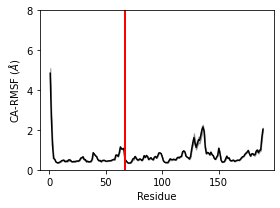

In [5]:
df = pd.read_csv('RMSF_data_chainA.csv')

ymax = 8

# secondary structure elements
# Beta strands based on DSSP:
#beta_start = [7,22,37,46,56,75,95]
#beta_end = [17,35,43,55,70,82,97]
#beta_start = np.array(beta_start)+0
#beta_end = np.array(beta_end)+0
#strand_names = ["S1","H1","S2","S3","H2","S4","S5"]

plt.figure(figsize = (4,3))

colors = ['black']
constructs = ['Isolated']

for c,con in zip(colors,constructs):
    plt.plot(df['Residue'],df['{} Avg.'.format(con)],color = c,label = con)
    plt.fill_between(df['Residue'],df['{} Avg.'.format(con)]-df['{} Err.'.format(con)],df['{} Avg.'.format(con)]+df['{} Err.'.format(con)],color = c,alpha = 0.3)
    

plt.ylim(0,ymax)
# secondary structure
#for i in range(len(beta_start)):
#    plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
#for i in range(len(beta_start)):
#    plt.text((beta_start[i]+beta_end[i])/2-1,ymax*0.85,strand_names[i],fontsize = 10)
    
# buried PTM sites
plt.axvline(67,color = 'red',linewidth=2)

    
plt.xlabel('Residue')
plt.ylabel('CA-RMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('RMSF_comparison_chainA.pdf')



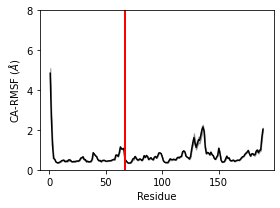

In [8]:
df = pd.read_csv('RMSF_data_chainA.csv')

ymax = 8

# secondary structure elements
# Beta strands based on DSSP:
#beta_start = [7,22,37,46,56,75,95]
#beta_end = [17,35,43,55,70,82,97]
#beta_start = np.array(beta_start)+0
#beta_end = np.array(beta_end)+0
#strand_names = ["S1","H1","S2","S3","H2","S4","S5"]

plt.figure(figsize = (4,3))

colors = ['black']
constructs = ['Isolated']

for c,con in zip(colors,constructs):
    plt.plot(df['Residue'],df['{} Avg.'.format(con)],color = c,label = con)
    plt.fill_between(df['Residue'],df['{} Avg.'.format(con)]-df['{} Err.'.format(con)],df['{} Avg.'.format(con)]+df['{} Err.'.format(con)],color = c,alpha = 0.3)
    

plt.ylim(0,ymax)
# secondary structure
#for i in range(len(beta_start)):
#    plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
#for i in range(len(beta_start)):
#    plt.text((beta_start[i]+beta_end[i])/2-1,ymax*0.85,strand_names[i],fontsize = 10)
    
# buried PTM sites
plt.axvline(67,color = 'red',linewidth=2)

    
plt.xlabel('Residue')
plt.ylabel('CA-RMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('RMSF_comparison_chainA.png')




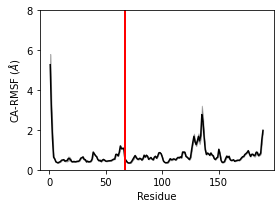

In [6]:
df = pd.read_csv('RMSF_data_chainB.csv')

ymax = 8

# secondary structure elements
# Beta strands based on DSSP:
#beta_start = [7,22,37,46,56,75,95]
#beta_end = [17,35,43,55,70,82,97]
#beta_start = np.array(beta_start)+0
#beta_end = np.array(beta_end)+0
#strand_names = ["S1","H1","S2","S3","H2","S4","S5"]

plt.figure(figsize = (4,3))

colors = ['black']
constructs = ['Isolated']

for c,con in zip(colors,constructs):
    plt.plot(df['Residue'],df['{} Avg.'.format(con)],color = c,label = con)
    plt.fill_between(df['Residue'],df['{} Avg.'.format(con)]-df['{} Err.'.format(con)],df['{} Avg.'.format(con)]+df['{} Err.'.format(con)],color = c,alpha = 0.3)
    

plt.ylim(0,ymax)
# secondary structure
#for i in range(len(beta_start)):
#    plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
#for i in range(len(beta_start)):
#    plt.text((beta_start[i]+beta_end[i])/2-1,ymax*0.85,strand_names[i],fontsize = 10)
    
# buried PTM sites
plt.axvline(67,color = 'red',linewidth=2)

    
plt.xlabel('Residue')
plt.ylabel('CA-RMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('RMSF_comparison_chainB.pdf')




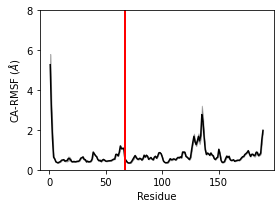

In [7]:
df = pd.read_csv('RMSF_data_chainB.csv')

ymax = 8

# secondary structure elements
# Beta strands based on DSSP:
#beta_start = [7,22,37,46,56,75,95]
#beta_end = [17,35,43,55,70,82,97]
#beta_start = np.array(beta_start)+0
#beta_end = np.array(beta_end)+0
#strand_names = ["S1","H1","S2","S3","H2","S4","S5"]

plt.figure(figsize = (4,3))

colors = ['black']
constructs = ['Isolated']

for c,con in zip(colors,constructs):
    plt.plot(df['Residue'],df['{} Avg.'.format(con)],color = c,label = con)
    plt.fill_between(df['Residue'],df['{} Avg.'.format(con)]-df['{} Err.'.format(con)],df['{} Avg.'.format(con)]+df['{} Err.'.format(con)],color = c,alpha = 0.3)
    

plt.ylim(0,ymax)
# secondary structure
#for i in range(len(beta_start)):
#    plt.axvspan(beta_start[i],beta_end[i],color = 'grey',alpha = 0.3)
#for i in range(len(beta_start)):
#    plt.text((beta_start[i]+beta_end[i])/2-1,ymax*0.85,strand_names[i],fontsize = 10)
    
# buried PTM sites
plt.axvline(67,color = 'red',linewidth=2)

    
plt.xlabel('Residue')
plt.ylabel('CA-RMSF ($\\AA$)')

plt.tight_layout()
plt.savefig('RMSF_comparison_chainB.png')



